# Playground Series S6E5 - F1 Pit Stops 예측 (EDA)

**목표:** `PitNextLap` (다음 랩 핏스톱 여부) 예측 — 이진 분류
**평가지표:** ROC AUC
**Train:** 439,140행 × 16열 / **Test:** 188,165행 × 15열 / 양성 비율: **19.9%**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

mpl.rcParams['font.family'] = 'Malgun Gothic'
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

train = pd.read_csv('../data/train.csv')
test  = pd.read_csv('../data/test.csv')

NUM_COLS = ['Year', 'PitStop', 'LapNumber', 'Stint', 'TyreLife', 'Position',
            'LapTime (s)', 'LapTime_Delta', 'Cumulative_Degradation',
            'RaceProgress', 'Position_Change']
CAT_COLS = ['Driver', 'Compound', 'Race']
TARGET = 'PitNextLap'
POS, NEG = '#e74c3c', '#3498db'

print(f'Train: {train.shape}  Test: {test.shape}')
print(f'결측치 Train: {train.isnull().sum().sum()} / Test: {test.isnull().sum().sum()}')
train.head()

C:\Users\Admin\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Train: (439140, 16)  Test: (188165, 15)
결측치 Train: 0 / Test: 0


,id,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


## 1. 타겟 분포

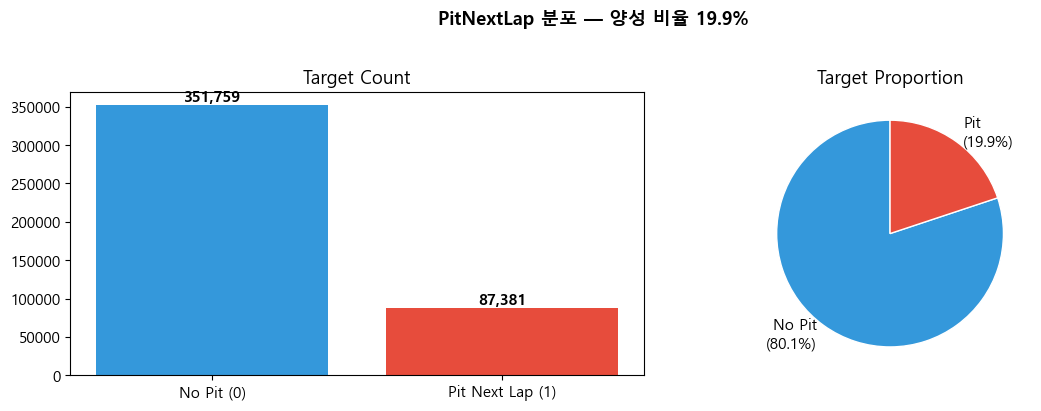

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
vc = train[TARGET].value_counts().sort_index()
axes[0].bar(['No Pit (0)', 'Pit Next Lap (1)'], vc.values, color=[NEG, POS])
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 5000, f'{v:,}', ha='center', fontweight='bold')
axes[0].set_title('Target Count')

pct = vc / len(train) * 100
axes[1].pie(pct.values, labels=[f'No Pit\n({pct.iloc[0]:.1f}%)', f'Pit\n({pct.iloc[1]:.1f}%)'],
            colors=[NEG, POS], startangle=90, wedgeprops={'edgecolor': 'white'})
axes[1].set_title('Target Proportion')

plt.suptitle(f'PitNextLap 분포 — 양성 비율 {train[TARGET].mean():.1%}', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 2. 수치형 피처 — 타겟별 분포

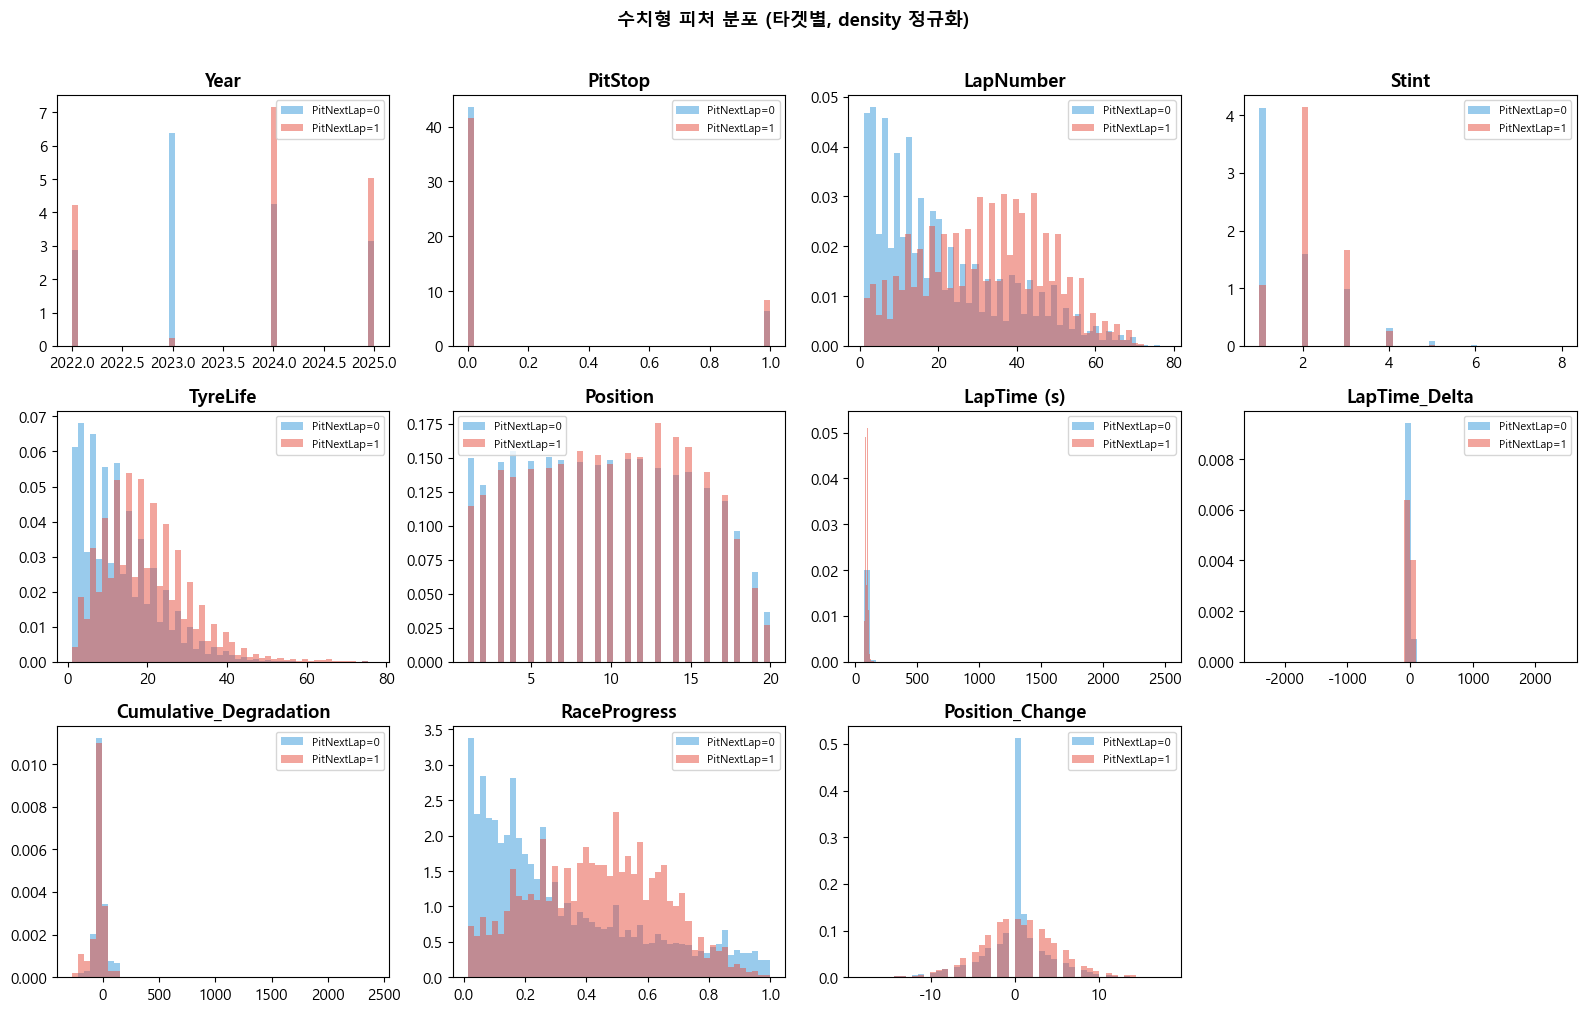

In [3]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    for label, color in [(0, NEG), (1, POS)]:
        subset = train[train[TARGET] == label][col]
        ax.hist(subset, bins=50, alpha=0.5, label=f'PitNextLap={label}', color=color, density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)
axes[-1].axis('off')
plt.suptitle('수치형 피처 분포 (타겟별, density 정규화)', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [4]:
# 양성/음성 그룹 평균 비교 + 판별력 (|차이|/표준편차)
mean_by_target = train.groupby(TARGET)[NUM_COLS].mean().T
mean_by_target.columns = ['No Pit', 'Pit Next']
mean_by_target['차이'] = mean_by_target['Pit Next'] - mean_by_target['No Pit']
mean_by_target['|차이|/표준편차'] = abs(mean_by_target['차이']) / train[NUM_COLS].std()
mean_by_target = mean_by_target.sort_values('|차이|/표준편차', ascending=False).round(3)
mean_by_target.style.background_gradient(subset=['|차이|/표준편차'], cmap='YlOrRd')

,No Pit,Pit Next,차이,|차이|/표준편차
TyreLife,12.822000,19.537000,6.715000,0.685000
LapNumber,20.849000,32.192000,11.344000,0.669000
Stint,1.695000,2.167000,0.472000,0.496000
RaceProgress,0.314000,0.432000,0.118000,0.465000
Cumulative_Degradation,-21.152000,-44.116000,-22.964000,0.419000
Year,2023.460000,2023.781000,0.322000,0.314000
PitStop,0.128000,0.170000,0.042000,0.122000
Position_Change,0.009000,0.473000,0.464000,0.116000
LapTime (s),91.285000,89.596000,-1.689000,0.085000
Position,9.574000,9.856000,0.282000,0.053000


## 3. 범주형 피처 vs 타겟

`Driver`는 카디널리티 887 → top-20만 표시. `Compound`/`Race`는 전체.

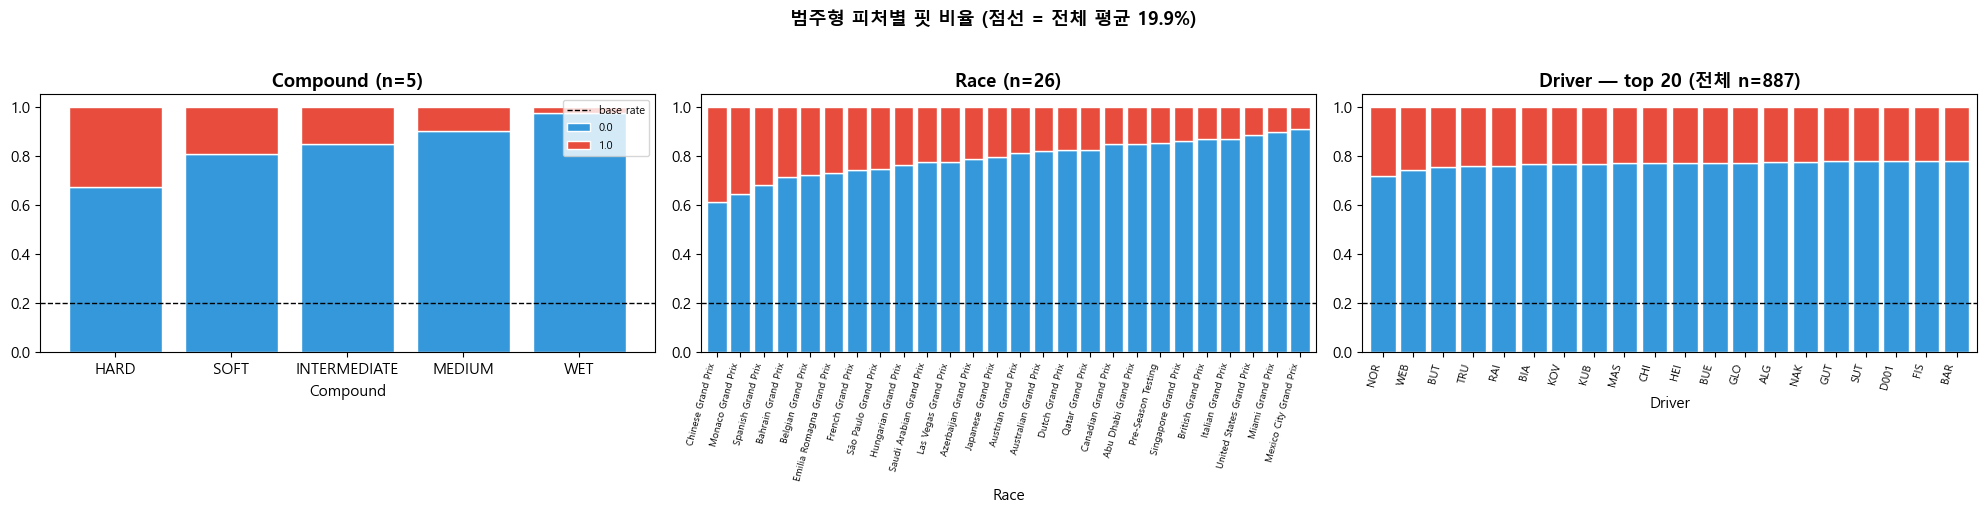

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Compound (5종)
ct = pd.crosstab(train['Compound'], train[TARGET], normalize='index').sort_values(1, ascending=False)
ct.plot(kind='bar', stacked=True, ax=axes[0], color=[NEG, POS], edgecolor='white', width=0.8)
axes[0].set_title(f'Compound (n={train["Compound"].nunique()})', fontweight='bold')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].axhline(train[TARGET].mean(), color='black', linestyle='--', linewidth=1, label='base rate')
axes[0].legend(fontsize=8, loc='upper right')

# Race (26개) — 핏 비율 순 정렬
ct = pd.crosstab(train['Race'], train[TARGET], normalize='index').sort_values(1, ascending=False)
ct.plot(kind='bar', stacked=True, ax=axes[1], color=[NEG, POS], edgecolor='white', width=0.85, legend=False)
axes[1].set_title(f'Race (n={train["Race"].nunique()})', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=75, ha='right', fontsize=7)
axes[1].axhline(train[TARGET].mean(), color='black', linestyle='--', linewidth=1)

# Driver — top 20 by row count
top_drv = train['Driver'].value_counts().head(20).index
ct = pd.crosstab(train.loc[train['Driver'].isin(top_drv), 'Driver'], train.loc[train['Driver'].isin(top_drv), TARGET], normalize='index').sort_values(1, ascending=False)
ct.plot(kind='bar', stacked=True, ax=axes[2], color=[NEG, POS], edgecolor='white', width=0.85, legend=False)
axes[2].set_title(f'Driver — top 20 (전체 n={train["Driver"].nunique()})', fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=75, ha='right', fontsize=8)
axes[2].axhline(train[TARGET].mean(), color='black', linestyle='--', linewidth=1)

plt.suptitle('범주형 피처별 핏 비율 (점선 = 전체 평균 19.9%)', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 4. 피처 간 상관관계

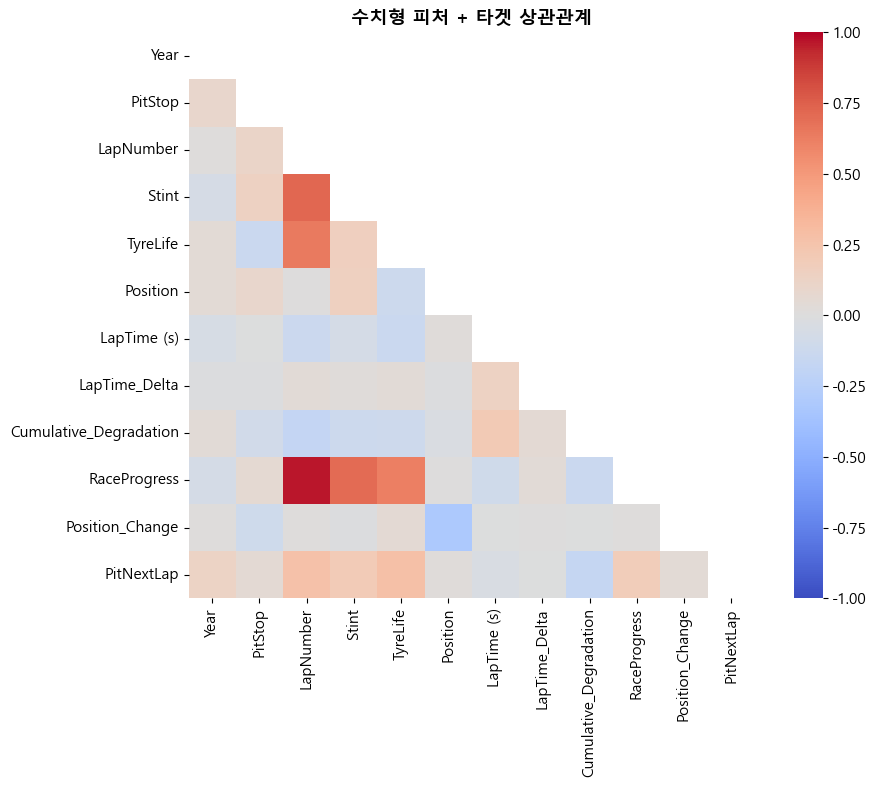

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))
corr = train[NUM_COLS + [TARGET]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title('수치형 피처 + 타겟 상관관계', fontweight='bold')
plt.tight_layout()
plt.show()

## 5. Train vs Test 분포 비교

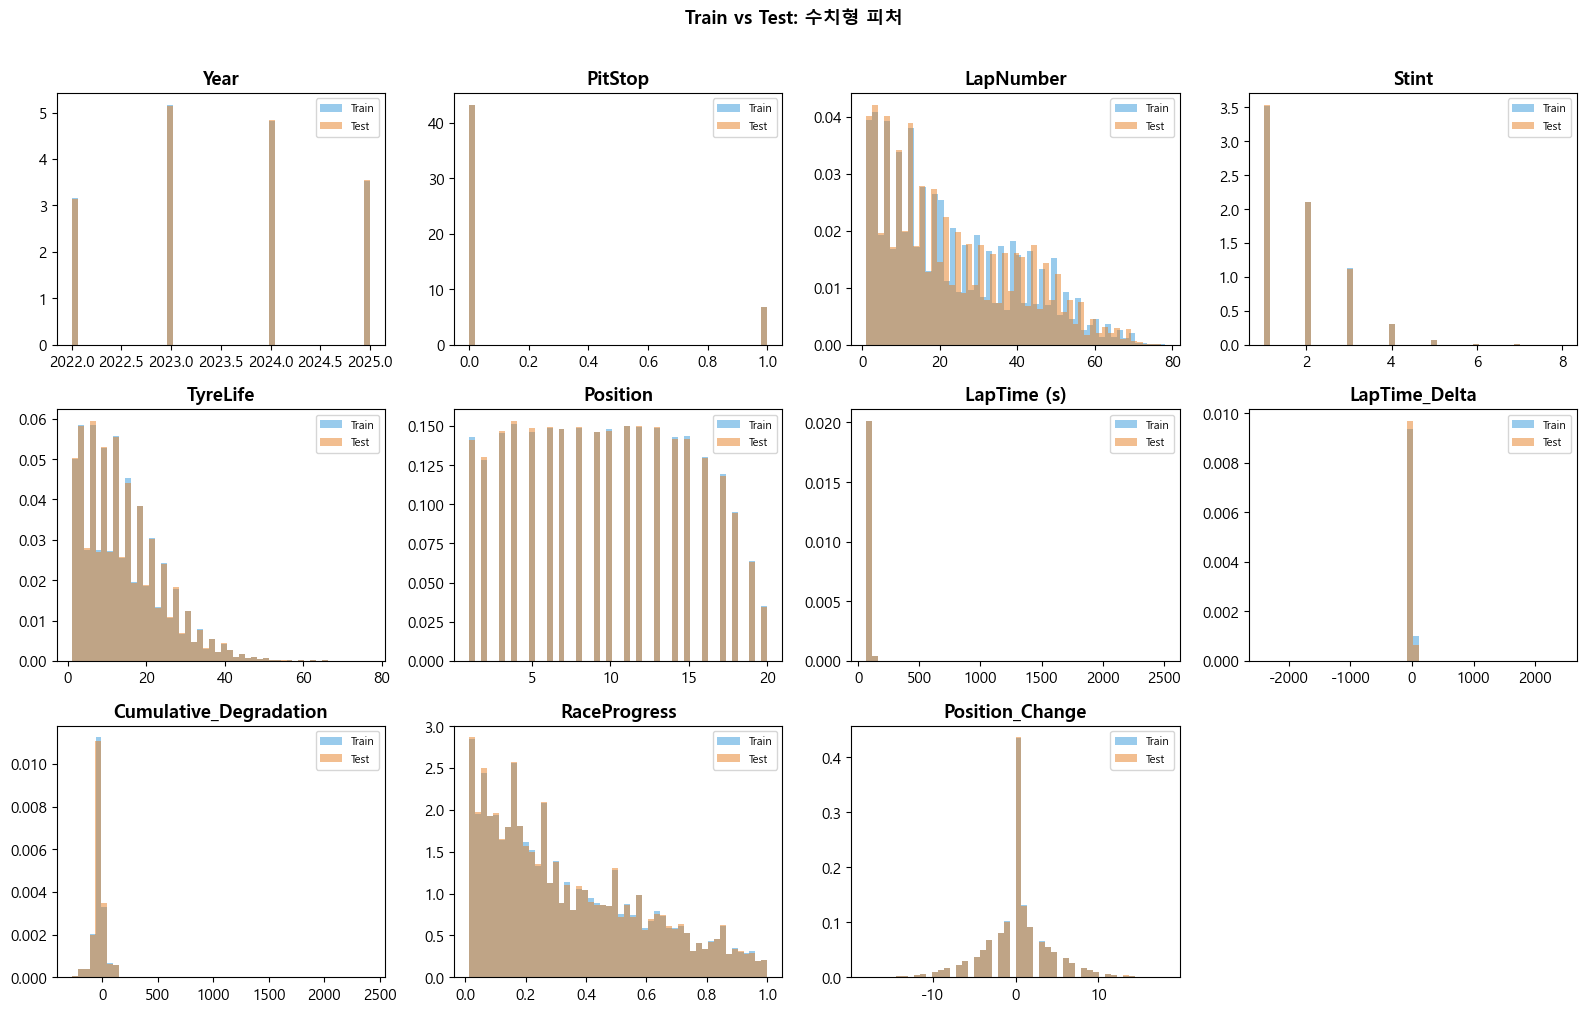

In [7]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, col in enumerate(NUM_COLS):
    ax = axes[i]
    ax.hist(train[col], bins=50, alpha=0.5, label='Train', color='#3498db', density=True)
    ax.hist(test[col],  bins=50, alpha=0.5, label='Test',  color='#e67e22', density=True)
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=8)
axes[-1].axis('off')
plt.suptitle('Train vs Test: 수치형 피처', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

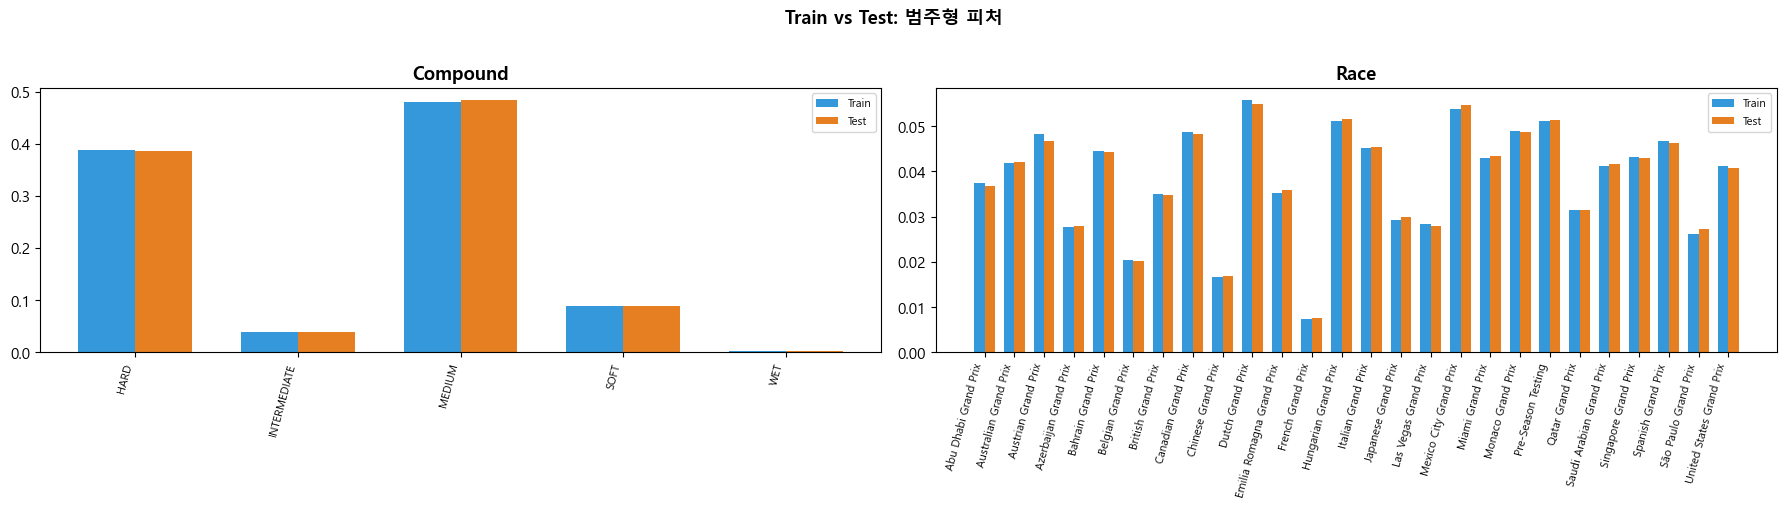

Driver — train: 887, test: 801, train-only: 86, test-only: 0


In [8]:
# 범주형: Compound / Race
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for ax, col in zip(axes, ['Compound', 'Race']):
    tr = train[col].value_counts(normalize=True).sort_index()
    te = test[col].value_counts(normalize=True).reindex(tr.index, fill_value=0)
    x = np.arange(len(tr))
    w = 0.35
    ax.bar(x - w/2, tr.values, w, label='Train', color='#3498db')
    ax.bar(x + w/2, te.values, w, label='Test',  color='#e67e22')
    ax.set_title(col, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(tr.index, rotation=75, ha='right', fontsize=8)
    ax.legend(fontsize=8)
plt.suptitle('Train vs Test: 범주형 피처', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# Driver overlap 점검
drv_tr = set(train['Driver'].unique())
drv_te = set(test['Driver'].unique())
print(f'Driver — train: {len(drv_tr)}, test: {len(drv_te)}, train-only: {len(drv_tr-drv_te)}, test-only: {len(drv_te-drv_tr)}')

## 6. F1 도메인 인사이트

핏스톱은 **타이어 노화/스틴트 길이**가 핵심 원인. 도메인적으로 가장 의미 있을 후보:
- `TyreLife` ↑ → 핏 확률 ↑ (hazard 곡선 예상)
- `RaceProgress`, `LapNumber` 따라 핏 패턴 다름
- `Compound`별 타이어 수명 → 핏 시점 다름 (HARD가 가장 길게 감)

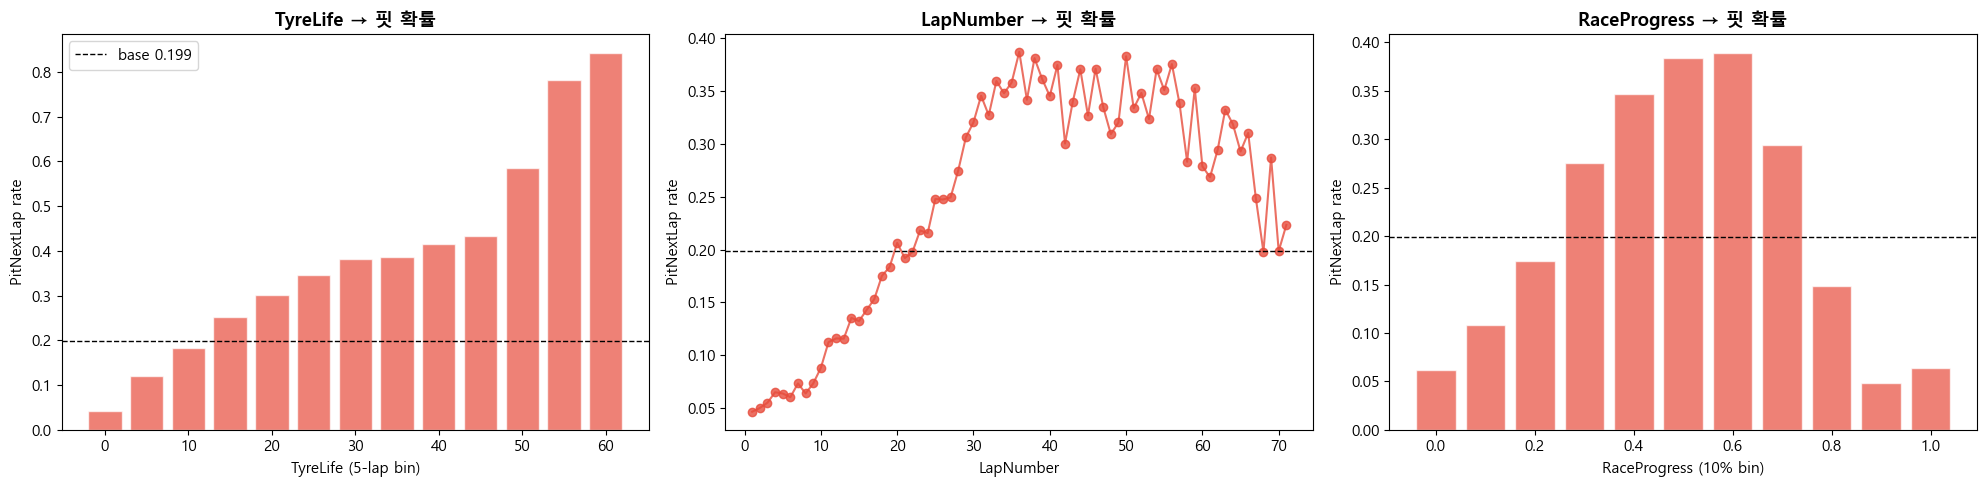

In [9]:
# 6-1) TyreLife 구간별 핏 비율 (10단위 binning)
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

train['_tyre_bin'] = (train['TyreLife'] // 5 * 5).astype(int)
g = train.groupby('_tyre_bin').agg(rate=(TARGET, 'mean'), n=(TARGET, 'size')).reset_index()
g = g[g['n'] >= 200]
ax = axes[0]
ax.bar(g['_tyre_bin'], g['rate'], width=4, color=POS, alpha=0.7, edgecolor='white')
ax.axhline(train[TARGET].mean(), color='black', linestyle='--', linewidth=1, label=f'base {train[TARGET].mean():.3f}')
ax.set_xlabel('TyreLife (5-lap bin)')
ax.set_ylabel('PitNextLap rate')
ax.set_title('TyreLife → 핏 확률', fontweight='bold')
ax.legend()
train.drop('_tyre_bin', axis=1, inplace=True)

# 6-2) LapNumber → 핏 비율
g = train.groupby('LapNumber').agg(rate=(TARGET, 'mean'), n=(TARGET, 'size')).reset_index()
g = g[g['n'] >= 200]
ax = axes[1]
ax.plot(g['LapNumber'], g['rate'], marker='o', color=POS, alpha=0.8)
ax.axhline(train[TARGET].mean(), color='black', linestyle='--', linewidth=1)
ax.set_xlabel('LapNumber')
ax.set_ylabel('PitNextLap rate')
ax.set_title('LapNumber → 핏 확률', fontweight='bold')

# 6-3) RaceProgress → 핏 비율 (10% 단위)
train['_rp_bin'] = (train['RaceProgress'] * 10).astype(int) / 10
g = train.groupby('_rp_bin').agg(rate=(TARGET, 'mean'), n=(TARGET, 'size')).reset_index()
ax = axes[2]
ax.bar(g['_rp_bin'], g['rate'], width=0.08, color=POS, alpha=0.7, edgecolor='white')
ax.axhline(train[TARGET].mean(), color='black', linestyle='--', linewidth=1)
ax.set_xlabel('RaceProgress (10% bin)')
ax.set_ylabel('PitNextLap rate')
ax.set_title('RaceProgress → 핏 확률', fontweight='bold')
train.drop('_rp_bin', axis=1, inplace=True)

plt.tight_layout()
plt.show()

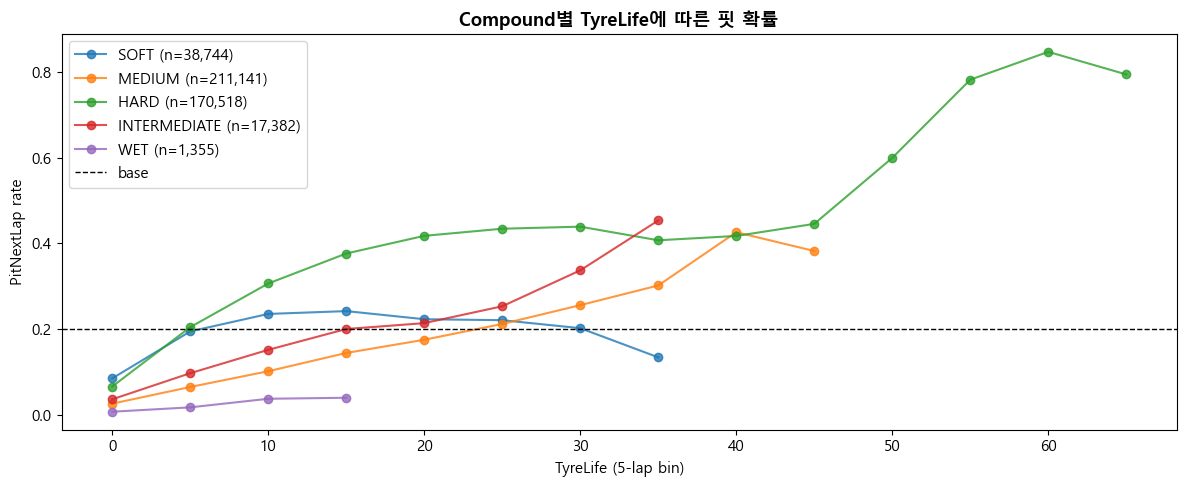

In [10]:
# 6-4) Compound × TyreLife → 핏 비율
fig, ax = plt.subplots(figsize=(12, 5))
train['_tyre_bin'] = (train['TyreLife'] // 5 * 5).astype(int)
for cmp in ['SOFT', 'MEDIUM', 'HARD', 'INTERMEDIATE', 'WET']:
    sub = train[train['Compound'] == cmp]
    if len(sub) == 0:
        continue
    g = sub.groupby('_tyre_bin').agg(rate=(TARGET, 'mean'), n=(TARGET, 'size')).reset_index()
    g = g[g['n'] >= 100]
    ax.plot(g['_tyre_bin'], g['rate'], marker='o', label=f'{cmp} (n={len(sub):,})', alpha=0.8)
ax.axhline(train[TARGET].mean(), color='black', linestyle='--', linewidth=1, label='base')
ax.set_xlabel('TyreLife (5-lap bin)')
ax.set_ylabel('PitNextLap rate')
ax.set_title('Compound별 TyreLife에 따른 핏 확률', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()
train.drop('_tyre_bin', axis=1, inplace=True)

## 7. PitStop / Stint / 데이터 정합성 점검

`PitStop`은 현재 랩 핏 여부, `PitNextLap`은 다음 랩 핏 여부.
PitStop=1과 PitNextLap=1이 동시에 양성인 케이스가 14k 있는데(연속 핏?) — 점검.

In [11]:
# PitStop x PitNextLap 교차표 + 비율
ct = pd.crosstab(train['PitStop'], train[TARGET], margins=True)
ct_norm = pd.crosstab(train['PitStop'], train[TARGET], normalize='index').round(4)
print('교차표 (count):')
print(ct)
print('\n행별 비율 (PitStop 조건부 핏 확률):')
print(ct_norm)

# Stint 분포
print('\nStint 분포:')
print(train['Stint'].value_counts().sort_index().to_string())
print('\nStint별 핏 확률:')
print(train.groupby('Stint')[TARGET].agg(['mean', 'size']).round(4).to_string())

교차표 (count):
PitNextLap     0.0    1.0     All
PitStop                          
0           306798  72567  379365
1            44961  14814   59775
All         351759  87381  439140

행별 비율 (PitStop 조건부 핏 확률):
PitNextLap     0.0     1.0
PitStop                   
0           0.8087  0.1913
1           0.7522  0.2478

Stint 분포:
Stint
1    216288
2    129536
3     69238
4     18903
5      4281
6       728
7       116
8        50

Stint별 핏 확률:
         mean    size
Stint                
1      0.0598  216288
2      0.3911  129536
3      0.2931   69238
4      0.1717   18903
5      0.0530    4281
6      0.0192     728
7      0.0000     116
8      0.0200      50


## 8. 요약

### 핵심 발견사항

| 항목 | 내용 |
|------|------|
| 양성 비율 | **19.9%** — 약간 불균형, AUC 평가라 클래스 weight 영향은 제한적 |
| 결측 | 없음 |
| Driver 카디널리티 | **887** (train-only 86) — 타깃 인코딩 / 빈도 인코딩 후보 |
| Race | 26개 (`Pre-Season Testing` 포함) |
| Compound | 5개 (HARD/MEDIUM/SOFT/INTERMEDIATE/WET) |
| Year | 4개 (2022–2025) |
| Train/Test 분포 | 거의 동일 — 분포 이동 없음 |

### 모델링 시사점
- **TyreLife / RaceProgress / LapNumber**가 핏 의사결정의 도메인적 주된 시그널
- `Compound × TyreLife` 인터랙션 — 컴파운드별 마모 곡선이 다름 → 모델이 자동 잡아낼지 / FE로 명시할지 검토
- 트리 기반(LGBM/XGB/CatBoost) 적합 — Driver는 CatBoost가 자연 처리 / 다른 모델은 인코딩 필요
- ID 순차 (train 0–439139, test 439140–627304) — 시계열 분리 가능성 확인 필요 (KFold vs GroupKFold by Driver/Race)
- `PitStop` 컬럼은 현재 랩 핏을 의미 — 잠재적 누수 위험은 없으나 의미 재확인 필요